# INTRODUCTION

Introduction

Sepsis is a life-threatening condition caused by a dysregulated immune response to infection and remains one of the leading causes of mortality in intensive care units (ICUs). A major clinical challenge in sepsis management is maintaining adequate blood pressure and organ perfusion in critically ill patients.

Vasopressors are medications commonly administered to septic patients experiencing hypotension or septic shock. While vasopressors can rapidly improve mean arterial pressure (MAP), excessive or inappropriate administration may lead to adverse cardiovascular effects and poor long-term outcomes. Therefore, determining the optimal timing and intensity of vasopressor administration is a complex sequential decision-making problem.

Reinforcement Learning (RL) provides a promising framework for modeling such treatment strategies because it learns policies through sequential state transitions and long-term reward optimization. Unlike traditional supervised learning approaches that imitate clinician behavior, RL attempts to identify actions that maximize cumulative future rewards over time.

In this project, an offline Deep Q-Network (DQN) based reinforcement learning pipeline was developed using the MIMIC-IV critical care database. Temporal patient states were constructed from hourly ICU measurements, and vasopressor administration was modeled as a binary treatment action. The project investigates how reward design and temporal feature engineering influence learned treatment policies in offline healthcare RL settings.

# DATA EXTRACTION

## Data Extraction and Cohort Construction



The dataset used in this project was derived from the MIMIC-IV (Medical Information Mart for Intensive Care IV) critical care database, which contains de-identified ICU patient records collected from Beth Israel Deaconess Medical Center.

Patient-level physiological measurements and treatment variables were extracted using Google BigQuery SQL queries. A sepsis-oriented cohort was constructed using ICU stay identifiers (stay_id) and time-aligned clinical measurements.

Hourly aggregation was performed to transform irregularly sampled ICU measurements into structured temporal state transitions suitable for reinforcement learning. For each ICU stay, physiological variables were grouped into one-hour time buckets using timestamp truncation operations.

The extracted features included:

Heart Rate (HR) 

Mean Arterial Pressure (MAP)

Respiratory Rate (RR

Oxygen Saturation (SpO₂)

Lactate measurements

SOFA (Sequential Organ Failure Assessment) scores

Vasopressor administration rates

SQL-based aggregation functions such as AVG() and temporal joins were used to compute hourly summaries for each patient trajectory. Missing values were handled during preprocessing and temporal alignment.

The resulting dataset consisted of sequential hourly patient states representing ICU trajectories over time.

# Data Extraction

## Code In BIGQUERY

In [ ]:
WITH rl_dataset AS (

    WITH transitions AS (

        WITH state_action_table AS (

            WITH sepsis_cohort AS (

                SELECT
                    s.subject_id,
                    s.stay_id,
                    i.hadm_id,
                    s.sofa_score,

                    ROW_NUMBER() OVER (
                        PARTITION BY s.subject_id
                        ORDER BY i.intime
                    ) AS rn

                FROM `physionet-data.mimiciv_3_1_derived.sepsis3` s

                JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
                ON s.stay_id = i.stay_id

                JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
                ON s.subject_id = p.subject_id

                WHERE p.anchor_age >= 18
            ),

            heart_rate AS (

                SELECT
                    ce.stay_id,
                    TIMESTAMP_TRUNC(ce.charttime, HOUR) AS hour_bucket,
                    AVG(ce.valuenum) AS avg_hr

                FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce

                JOIN sepsis_cohort sc
                ON ce.stay_id = sc.stay_id

                WHERE sc.rn = 1
                AND ce.itemid = 220045
                AND ce.valuenum BETWEEN 30 AND 220

                GROUP BY ce.stay_id, hour_bucket
            ),

            map_data AS (

                SELECT
                    ce.stay_id,
                    TIMESTAMP_TRUNC(ce.charttime, HOUR) AS hour_bucket,
                    AVG(ce.valuenum) AS avg_map

                FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce

                JOIN sepsis_cohort sc
                ON ce.stay_id = sc.stay_id

                WHERE sc.rn = 1
                AND ce.itemid = 220181
                AND ce.valuenum BETWEEN 20 AND 200

                GROUP BY ce.stay_id, hour_bucket
            ),

            rr_data AS (

                SELECT
                    ce.stay_id,
                    TIMESTAMP_TRUNC(ce.charttime, HOUR) AS hour_bucket,
                    AVG(ce.valuenum) AS avg_rr

                FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce

                JOIN sepsis_cohort sc
                ON ce.stay_id = sc.stay_id

                WHERE sc.rn = 1
                AND ce.itemid = 220210
                AND ce.valuenum BETWEEN 5 AND 80

                GROUP BY ce.stay_id, hour_bucket
            ),

            spo2_data AS (

                SELECT
                    ce.stay_id,
                    TIMESTAMP_TRUNC(ce.charttime, HOUR) AS hour_bucket,
                    AVG(ce.valuenum) AS avg_spo2

                FROM `physionet-data.mimiciv_3_1_icu.chartevents` ce

                JOIN sepsis_cohort sc
                ON ce.stay_id = sc.stay_id

                WHERE sc.rn = 1
                AND ce.itemid = 220277
                AND ce.valuenum BETWEEN 50 AND 100

                GROUP BY ce.stay_id, hour_bucket
            ),

            lactate_data AS (

                SELECT
                    sc.stay_id,
                    TIMESTAMP_TRUNC(le.charttime, HOUR) AS hour_bucket,
                    AVG(le.valuenum) AS avg_lactate

                FROM `physionet-data.mimiciv_3_1_hosp.labevents` le

                JOIN sepsis_cohort sc
                ON le.hadm_id = sc.hadm_id

                WHERE sc.rn = 1
                AND le.itemid = 50813
                AND le.valuenum BETWEEN 0.2 AND 30

                GROUP BY sc.stay_id, hour_bucket
            ),

            vasopressor_data AS (

                SELECT
                    ie.stay_id,
                    TIMESTAMP_TRUNC(ie.starttime, HOUR) AS hour_bucket,
                    AVG(ie.rate) AS avg_vaso_rate

                FROM `physionet-data.mimiciv_3_1_icu.inputevents` ie

                JOIN sepsis_cohort sc
                ON ie.stay_id = sc.stay_id

                WHERE sc.rn = 1

                AND ie.itemid IN (
                    221906,
                    221289,
                    221662,
                    222315
                )

                AND ie.rate IS NOT NULL

                GROUP BY ie.stay_id, hour_bucket
            )

            SELECT
                hr.stay_id,
                hr.hour_bucket,

                hr.avg_hr,
                mp.avg_map,
                rr.avg_rr,
                sp.avg_spo2,
                ld.avg_lactate,

                sc.sofa_score,

                COALESCE(vd.avg_vaso_rate, 0) AS vaso_action

            FROM heart_rate hr

            JOIN map_data mp
            ON hr.stay_id = mp.stay_id
            AND hr.hour_bucket = mp.hour_bucket

            JOIN rr_data rr
            ON hr.stay_id = rr.stay_id
            AND hr.hour_bucket = rr.hour_bucket

            JOIN spo2_data sp
            ON hr.stay_id = sp.stay_id
            AND hr.hour_bucket = sp.hour_bucket

            LEFT JOIN lactate_data ld
            ON hr.stay_id = ld.stay_id
            AND hr.hour_bucket = ld.hour_bucket

            LEFT JOIN vasopressor_data vd
            ON hr.stay_id = vd.stay_id
            AND hr.hour_bucket = vd.hour_bucket

            JOIN sepsis_cohort sc
            ON hr.stay_id = sc.stay_id

            WHERE sc.rn = 1
        )

        SELECT
            *,

            LEAD(avg_hr) OVER (
                PARTITION BY stay_id
                ORDER BY hour_bucket
            ) AS next_hr,

            LEAD(avg_map) OVER (
                PARTITION BY stay_id
                ORDER BY hour_bucket
            ) AS next_map

        FROM state_action_table
    )

    SELECT
        *,

        CASE
            WHEN next_map >= 65 THEN 1
            WHEN next_map < 65 THEN -1
            ELSE 0
        END AS reward

    FROM transitions
)

SELECT *

FROM rl_dataset

WHERE next_hr IS NOT NULL
AND next_map IS NOT NULL

ORDER BY
    stay_id,
    hour_bucket

LIMIT 100;

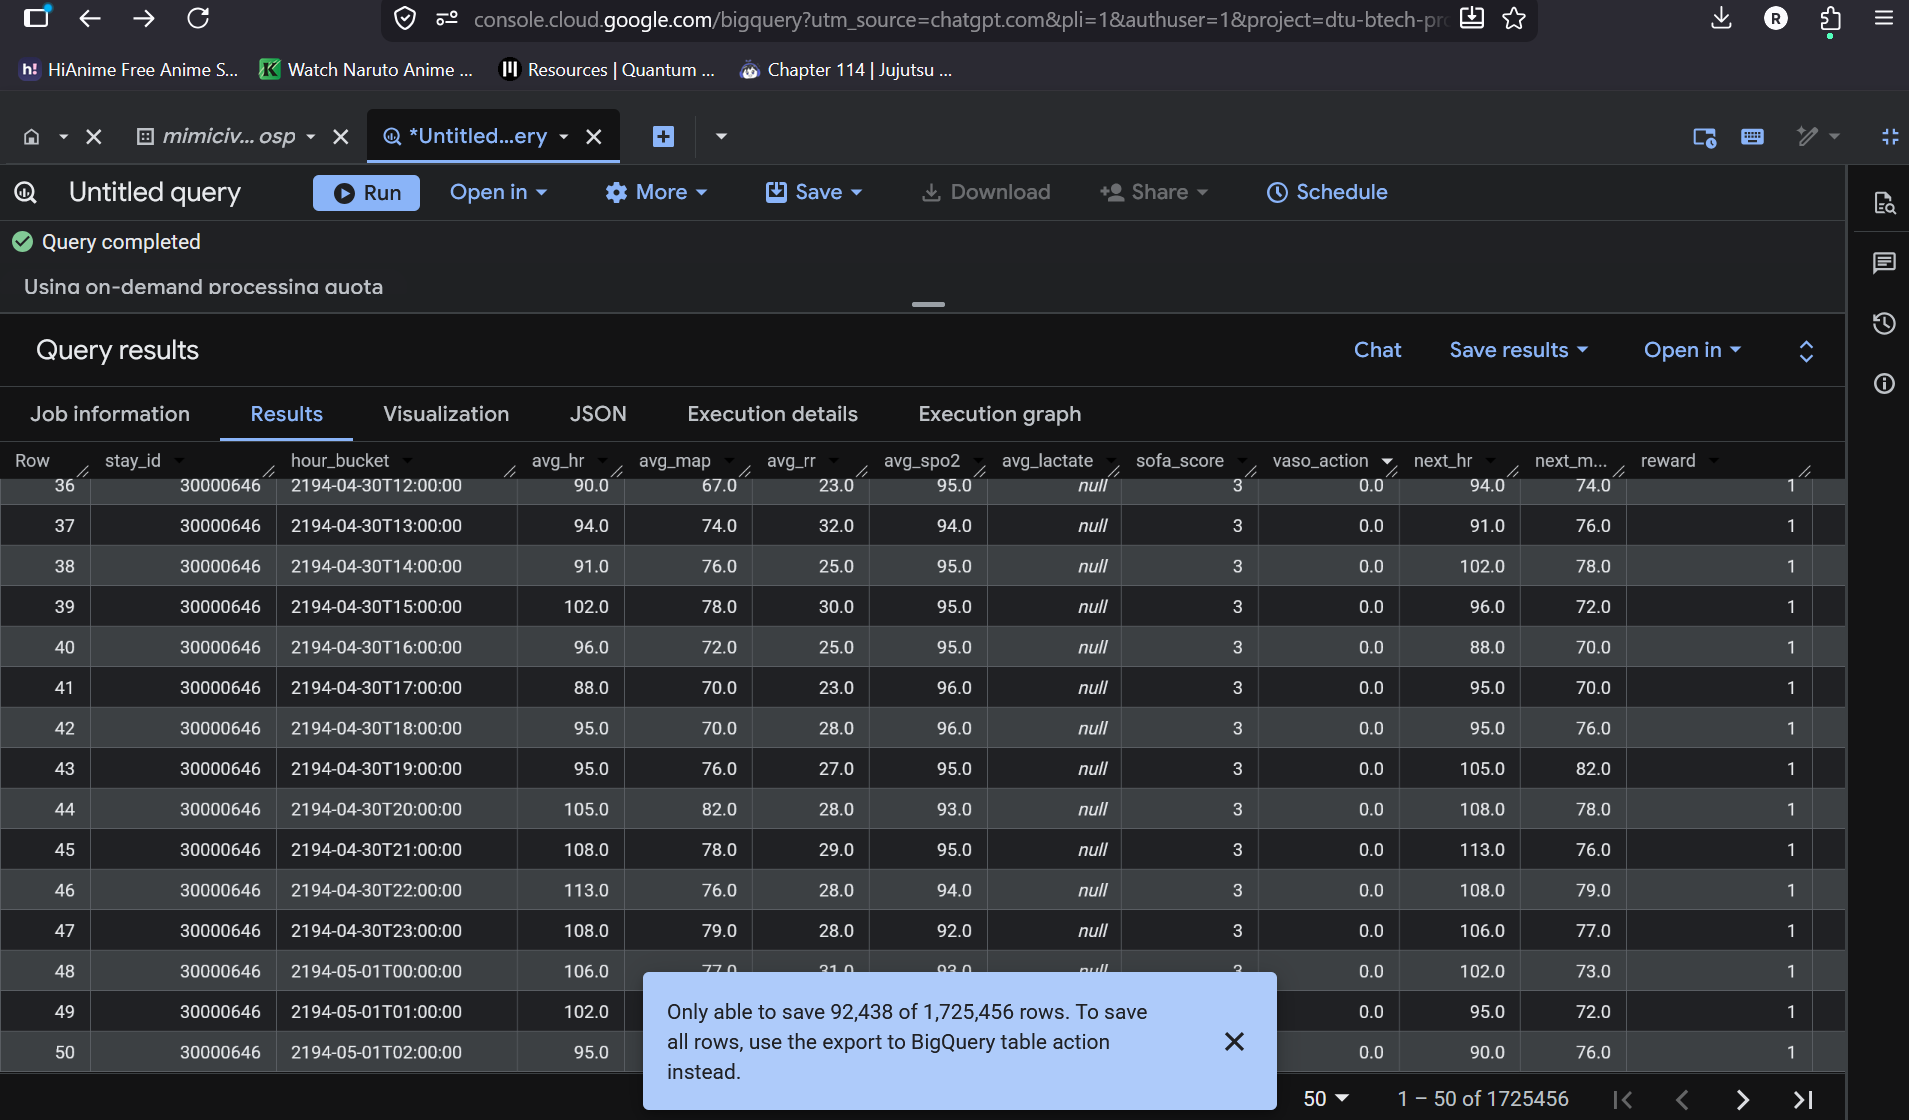

In [64]:
from IPython.display import Image

Image(filename="RL/Main ss.png")

# Behavior Cloning Baseline

In [1]:
import pandas as pd

df = pd.read_csv("RL/rl_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)

    stay_id          hour_bucket  avg_hr  avg_map  avg_rr  avg_spo2  \
0  30000646  2194-04-29T01:00:00   100.0     77.5    28.0      97.5   
1  30000646  2194-04-29T02:00:00   102.0     75.0    33.0      98.0   
2  30000646  2194-04-29T03:00:00    97.0     67.0    19.0      94.0   
3  30000646  2194-04-29T04:00:00    93.0     67.0    18.0      98.0   
4  30000646  2194-04-29T05:00:00    88.0     73.0    28.0      94.5   

   avg_lactate  sofa_score  vaso_action  next_hr   next_map  reward  
0          NaN           3          0.0    102.0  75.000000       1  
1          NaN           3          0.0     97.0  67.000000       1  
2          NaN           3          0.0     93.0  67.000000       1  
3          NaN           3          0.0     88.0  73.000000       1  
4          NaN           3          0.0     91.5  64.454545      -1  
(92438, 12)
Index(['stay_id', 'hour_bucket', 'avg_hr', 'avg_map', 'avg_rr', 'avg_spo2',
       'avg_lactate', 'sofa_score', 'vaso_action', 'next_hr', 'ne

In [2]:
df.head()
df.shape
df.isnull().sum()

stay_id            0
hour_bucket        0
avg_hr             0
avg_map            0
avg_rr             0
avg_spo2           0
avg_lactate    89972
sofa_score         0
vaso_action        0
next_hr            0
next_map           0
reward             0
dtype: int64

In [3]:
df["avg_lactate"] = df["avg_lactate"].fillna(
    df["avg_lactate"].median()
)

print(df.isnull().sum())

stay_id        0
hour_bucket    0
avg_hr         0
avg_map        0
avg_rr         0
avg_spo2       0
avg_lactate    0
sofa_score     0
vaso_action    0
next_hr        0
next_map       0
reward         0
dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler

state_cols = [
    "avg_hr",
    "avg_map",
    "avg_rr",
    "avg_spo2",
    "avg_lactate",
    "sofa_score"
]

scaler = StandardScaler()

df[state_cols] = scaler.fit_transform(
    df[state_cols]
)

print(df[state_cols].head())

     avg_hr   avg_map    avg_rr  avg_spo2  avg_lactate  sofa_score
0  0.783036 -0.028369  1.251617  0.279576    -0.049539   -0.345842
1  0.894575 -0.192215  2.099227  0.456143    -0.049539   -0.345842
2  0.615727 -0.716522 -0.274082 -0.956393    -0.049539   -0.345842
3  0.392648 -0.716522 -0.443604  0.456143    -0.049539   -0.345842
4  0.113800 -0.323292  1.251617 -0.779826    -0.049539   -0.345842


In [5]:
from sklearn.model_selection import train_test_split

unique_stays = df["stay_id"].unique()

train_stays, test_stays = train_test_split(
    unique_stays,
    test_size=0.2,
    random_state=42
)

train_df = df[
    df["stay_id"].isin(train_stays)
]

test_df = df[
    df["stay_id"].isin(test_stays)
]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "Unique train stays:",
    train_df["stay_id"].nunique()
)

print(
    "Unique test stays:",
    test_df["stay_id"].nunique()
)

Train shape: (71472, 12)
Test shape: (20966, 12)
Unique train stays: 1073
Unique test stays: 269


In [6]:
import numpy as np

state_cols = [
    "avg_hr",
    "avg_map",
    "avg_rr",
    "avg_spo2",
    "avg_lactate",
    "sofa_score"
]

next_state_cols = [
    "next_hr",
    "next_map"
]

# TRAIN ARRAYS

states_train = train_df[state_cols].values

actions_train = train_df["vaso_action"].values

rewards_train = train_df["reward"].values

next_states_train = train_df[
    next_state_cols
].values

# TEST ARRAYS

states_test = test_df[state_cols].values

actions_test = test_df["vaso_action"].values

rewards_test = test_df["reward"].values

next_states_test = test_df[
    next_state_cols
].values

print(states_train.shape)
print(actions_train.shape)
print(rewards_train.shape)
print(next_states_train.shape)

(71472, 6)
(71472,)
(71472,)
(71472, 2)


In [7]:
def discretize_action(x):

    if x == 0:
        return 0

    elif x <= 0.1:
        return 1

    elif x <= 0.5:
        return 2

    else:
        return 3


train_df["action_discrete"] = train_df[
    "vaso_action"
].apply(discretize_action)

test_df["action_discrete"] = test_df[
    "vaso_action"
].apply(discretize_action)

print(
    train_df["action_discrete"]
    .value_counts()
    .sort_index()
)

action_discrete
0    68906
1     1287
2      960
3      319
Name: count, dtype: int64


C:\Users\rsdha\AppData\Local\Temp\ipykernel_30900\2224321433.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["action_discrete"] = train_df[
C:\Users\rsdha\AppData\Local\Temp\ipykernel_30900\2224321433.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["action_discrete"] = test_df[


## imbalance problem

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# FEATURES
X_train = train_df[state_cols]
y_train = train_df["action_discrete"]

X_test = test_df[state_cols]
y_test = test_df["action_discrete"]

# BALANCED MODEL
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# TRAIN
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)

# REPORT
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     20161
           1       0.00      0.00      0.00       370
           2       0.00      0.00      0.00       372
           3       1.00      0.02      0.03        63

    accuracy                           0.96     20966
   macro avg       0.49      0.25      0.25     20966
weighted avg       0.93      0.96      0.94     20966



In [9]:
train_df_binary = train_df.copy()
test_df_binary = test_df.copy()

train_df_binary["action_binary"] = (
    train_df_binary["action_discrete"] > 0
).astype(int)

test_df_binary["action_binary"] = (
    test_df_binary["action_discrete"] > 0
).astype(int)

print(
    train_df_binary["action_binary"]
    .value_counts()
)

action_binary
0    68906
1     2566
Name: count, dtype: int64


## temporal feature improvement

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# FEATURES
X_train = train_df_binary[state_cols]
y_train = train_df_binary["action_binary"]

X_test = test_df_binary[state_cols]
y_test = test_df_binary["action_binary"]

# MODEL
binary_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# TRAIN
binary_model.fit(X_train, y_train)

# PREDICT
y_pred_binary = binary_model.predict(X_test)

# REPORT
print(
    classification_report(
        y_test,
        y_pred_binary
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     20161
           1       0.23      0.01      0.02       805

    accuracy                           0.96     20966
   macro avg       0.59      0.51      0.50     20966
weighted avg       0.93      0.96      0.94     20966



In [11]:
df_temporal = df.copy()

df_temporal = df_temporal.sort_values(
    ["stay_id", "hour_bucket"]
)

# Previous timestep features
df_temporal["prev_map"] = (
    df_temporal
    .groupby("stay_id")["avg_map"]
    .shift(1)
)

df_temporal["prev_hr"] = (
    df_temporal
    .groupby("stay_id")["avg_hr"]
    .shift(1)
)

# Trend features
df_temporal["delta_map"] = (
    df_temporal["avg_map"]
    - df_temporal["prev_map"]
)

df_temporal["delta_hr"] = (
    df_temporal["avg_hr"]
    - df_temporal["prev_hr"]
)

print(
    df_temporal[
        [
            "avg_map",
            "prev_map",
            "delta_map"
        ]
    ].head(10)
)

    avg_map  prev_map  delta_map
0 -0.028369       NaN        NaN
1 -0.192215 -0.028369  -0.163846
2 -0.716522 -0.192215  -0.524308
3 -0.716522 -0.716522   0.000000
4 -0.323292 -0.716522   0.393231
5 -0.883348 -0.323292  -0.560056
6 -1.262676 -0.883348  -0.379329
7 -1.437445 -1.262676  -0.174769
8 -0.945907 -1.437445   0.491538
9 -0.126677 -0.945907   0.819230


In [12]:
df_temporal_clean = df_temporal.dropna()

print(df_temporal_clean.shape)

print(
    df_temporal_clean[
        [
            "avg_map",
            "prev_map",
            "delta_map"
        ]
    ].head()
)

(91096, 16)
    avg_map  prev_map  delta_map
1 -0.192215 -0.028369  -0.163846
2 -0.716522 -0.192215  -0.524308
3 -0.716522 -0.716522   0.000000
4 -0.323292 -0.716522   0.393231
5 -0.883348 -0.323292  -0.560056


In [13]:
from sklearn.model_selection import train_test_split

unique_stays_temporal = (
    df_temporal_clean["stay_id"]
    .unique()
)

train_stays_temp, test_stays_temp = (
    train_test_split(
        unique_stays_temporal,
        test_size=0.2,
        random_state=42
    )
)

train_df_temp = df_temporal_clean[
    df_temporal_clean["stay_id"]
    .isin(train_stays_temp)
].copy()

test_df_temp = df_temporal_clean[
    df_temporal_clean["stay_id"]
    .isin(test_stays_temp)
].copy()

print(train_df_temp.shape)
print(test_df_temp.shape)

(69708, 16)
(21388, 16)


In [14]:
train_df_temp_binary = train_df_temp.copy()
test_df_temp_binary = test_df_temp.copy()

def discretize_action(x):

    if x == 0:
        return 0

    elif x <= 0.1:
        return 1

    elif x <= 0.5:
        return 2

    else:
        return 3


# recreate discrete actions
train_df_temp_binary["action_discrete"] = (
    train_df_temp_binary["vaso_action"]
    .apply(discretize_action)
)

test_df_temp_binary["action_discrete"] = (
    test_df_temp_binary["vaso_action"]
    .apply(discretize_action)
)

# binary conversion
train_df_temp_binary["action_binary"] = (
    train_df_temp_binary["action_discrete"] > 0
).astype(int)

test_df_temp_binary["action_binary"] = (
    test_df_temp_binary["action_discrete"] > 0
).astype(int)

print(
    train_df_temp_binary["action_binary"]
    .value_counts()
)

action_binary
0    67285
1     2423
Name: count, dtype: int64


## Offline RL Setup

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

temporal_state_cols = [

    "avg_hr",
    "avg_map",
    "avg_rr",
    "avg_spo2",
    "avg_lactate",
    "sofa_score",

    "prev_hr",
    "prev_map",

    "delta_hr",
    "delta_map"
]

# FEATURES
X_train_temp = train_df_temp_binary[
    temporal_state_cols
]

y_train_temp = train_df_temp_binary[
    "action_binary"
]

X_test_temp = test_df_temp_binary[
    temporal_state_cols
]

y_test_temp = test_df_temp_binary[
    "action_binary"
]

# MODEL
temporal_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# TRAIN
temporal_model.fit(
    X_train_temp,
    y_train_temp
)

# PREDICT
y_pred_temp = temporal_model.predict(
    X_test_temp
)

# EVALUATE
print(
    classification_report(
        y_test_temp,
        y_pred_temp
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     20613
           1       0.38      0.01      0.01       775

    accuracy                           0.96     21388
   macro avg       0.67      0.50      0.50     21388
weighted avg       0.94      0.96      0.95     21388



In [16]:
# probabilities for class 1
y_prob_temp = temporal_model.predict_proba(
    X_test_temp
)[:, 1]

# custom threshold
threshold = 0.2

y_pred_threshold = (
    y_prob_temp >= threshold
).astype(int)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_temp,
        y_pred_threshold
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     20613
           1       0.22      0.11      0.15       775

    accuracy                           0.95     21388
   macro avg       0.59      0.55      0.56     21388
weighted avg       0.94      0.95      0.95     21388



In [17]:
import pandas as pd

feature_importance_df = pd.DataFrame({

    "feature": temporal_state_cols,

    "importance": temporal_model.feature_importances_

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
)

print(feature_importance_df)

       feature  importance
1      avg_map    0.133850
5   sofa_score    0.122639
7     prev_map    0.120555
6      prev_hr    0.110400
0       avg_hr    0.108563
2       avg_rr    0.103109
9    delta_map    0.098013
8     delta_hr    0.097920
3     avg_spo2    0.073938
4  avg_lactate    0.031013


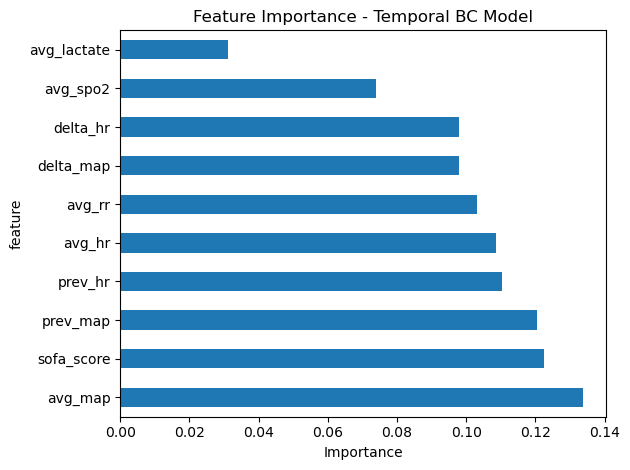

In [18]:
import matplotlib.pyplot as plt

feature_importance_df.plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title(
    "Feature Importance - Temporal BC Model"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [19]:
import numpy as np

# STATES
states = train_df_temp_binary[
    temporal_state_cols
].values.astype(np.float32)

# ACTIONS
actions = train_df_temp_binary[
    "action_binary"
].values.astype(np.int64)

# REWARDS
rewards = train_df_temp_binary[
    "reward"
].values.astype(np.float32)

# NEXT STATES
next_states = train_df_temp_binary[
    temporal_state_cols
].shift(-1).fillna(0).values.astype(np.float32)

print(states.shape)
print(actions.shape)
print(rewards.shape)
print(next_states.shape)

(69708, 10)
(69708,)
(69708,)
(69708, 10)


In [20]:
import torch
import torch.nn as nn

# device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

class DQN(nn.Module):

    def __init__(self, state_dim, action_dim):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):

        return self.network(x)


state_dim = states.shape[1]
action_dim = 2

dqn = DQN(
    state_dim,
    action_dim
).to(device)

print(dqn)

cpu
DQN(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
# STATES
states_tensor = torch.tensor(
    states,
    dtype=torch.float32
).to(device)

# ACTIONS
actions_tensor = torch.tensor(
    actions,
    dtype=torch.long
).to(device)

# REWARDS
rewards_tensor = torch.tensor(
    rewards,
    dtype=torch.float32
).to(device)

# NEXT STATES
next_states_tensor = torch.tensor(
    next_states,
    dtype=torch.float32
).to(device)

print(states_tensor.shape)
print(actions_tensor.shape)

torch.Size([69708, 10])
torch.Size([69708])


In [22]:
import torch.optim as optim

# optimizer
optimizer = optim.Adam(
    dqn.parameters(),
    lr=1e-3
)

# discount factor
gamma = 0.99

print("Optimizer and gamma initialized.")

Optimizer and gamma initialized.


In [23]:
# current Q-values
q_values = dqn(states_tensor)

# select Q-values for taken actions
current_q = q_values.gather(
    1,
    actions_tensor.unsqueeze(1)
).squeeze(1)

# next Q-values
with torch.no_grad():

    next_q_values = dqn(next_states_tensor)

    max_next_q = next_q_values.max(dim=1)[0]

# Bellman target
target_q = rewards_tensor + (
    gamma * max_next_q
)

# loss
loss_fn = nn.MSELoss()

loss = loss_fn(
    current_q,
    target_q
)

print("Loss:", loss.item())

Loss: 1.0125539302825928


In [24]:
# zero gradients
optimizer.zero_grad()

# backpropagation
loss.backward()

# parameter update
optimizer.step()

print("One DQN training step completed.")

One DQN training step completed.


In [25]:
num_epochs = 100

losses = []

for epoch in range(num_epochs):

    # current Q-values
    q_values = dqn(states_tensor)

    current_q = q_values.gather(
        1,
        actions_tensor.unsqueeze(1)
    ).squeeze(1)

    # target Q-values
    with torch.no_grad():

        next_q_values = dqn(
            next_states_tensor
        )

        max_next_q = next_q_values.max(
            dim=1
        )[0]

        target_q = rewards_tensor + (
            gamma * max_next_q
        )

    # loss
    loss = loss_fn(
        current_q,
        target_q
    )

    # optimization
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 1.0047
Epoch 10, Loss: 1.2630
Epoch 20, Loss: 2.1636
Epoch 30, Loss: 4.2621
Epoch 40, Loss: 7.8332
Epoch 50, Loss: 10.7521
Epoch 60, Loss: 12.2096
Epoch 70, Loss: 13.6410
Epoch 80, Loss: 14.9648
Epoch 90, Loss: 14.9248


In [26]:
# reinitialize network
dqn = DQN(
    state_dim,
    action_dim
).to(device)

# smaller learning rate
optimizer = optim.Adam(
    dqn.parameters(),
    lr=1e-4
)

print("DQN reset with smaller LR.")

DQN reset with smaller LR.


In [27]:
num_epochs = 100

losses = []

for epoch in range(num_epochs):

    # current Q-values
    q_values = dqn(states_tensor)

    current_q = q_values.gather(
        1,
        actions_tensor.unsqueeze(1)
    ).squeeze(1)

    # target Q-values
    with torch.no_grad():

        next_q_values = dqn(
            next_states_tensor
        )

        max_next_q = next_q_values.max(
            dim=1
        )[0]

        target_q = rewards_tensor + (
            gamma * max_next_q
        )

    # loss
    loss = loss_fn(
        current_q,
        target_q
    )

    # optimization
    optimizer.zero_grad()

    loss.backward()

    # gradient clipping
    torch.nn.utils.clip_grad_norm_(
        dqn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 1.0453
Epoch 10, Loss: 1.0155
Epoch 20, Loss: 1.0244
Epoch 30, Loss: 1.0395
Epoch 40, Loss: 1.0588
Epoch 50, Loss: 1.0829
Epoch 60, Loss: 1.1122
Epoch 70, Loss: 1.1471
Epoch 80, Loss: 1.1885
Epoch 90, Loss: 1.2365


In [28]:
import copy

target_dqn = copy.deepcopy(dqn)

target_dqn.eval()

print("Target network initialized.")

Target network initialized.


In [29]:
num_epochs = 100

losses = []

for epoch in range(num_epochs):

    # current Q-values
    q_values = dqn(states_tensor)

    current_q = q_values.gather(
        1,
        actions_tensor.unsqueeze(1)
    ).squeeze(1)

    # TARGET NETWORK
    with torch.no_grad():

        next_q_values = target_dqn(
            next_states_tensor
        )

        max_next_q = next_q_values.max(
            dim=1
        )[0]

        target_q = rewards_tensor + (
            gamma * max_next_q
        )

    # loss
    loss = loss_fn(
        current_q,
        target_q
    )

    # optimization
    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        dqn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    losses.append(loss.item())

    # periodically update target network
    if epoch % 10 == 0:

        target_dqn.load_state_dict(
            dqn.state_dict()
        )

        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 1.2913
Epoch 10, Loss: 1.1445
Epoch 20, Loss: 1.2001
Epoch 30, Loss: 1.2608
Epoch 40, Loss: 1.3274
Epoch 50, Loss: 1.3998
Epoch 60, Loss: 1.4776
Epoch 70, Loss: 1.5606
Epoch 80, Loss: 1.6483
Epoch 90, Loss: 1.7409


In [30]:
with torch.no_grad():

    q_values = dqn(states_tensor)

    learned_actions = q_values.argmax(
        dim=1
    ).cpu().numpy()

import numpy as np

unique, counts = np.unique(
    learned_actions,
    return_counts=True
)

print(
    dict(zip(unique, counts))
)

{np.int64(0): np.int64(69708)}


In [31]:
df_reward = df_temporal_clean.copy()

df_reward["reward_delta_map"] = (
    df_reward["next_map"]
    - df_reward["avg_map"]
)

print(
    df_reward[
        [
            "avg_map",
            "next_map",
            "reward_delta_map"
        ]
    ].head()
)

    avg_map   next_map  reward_delta_map
1 -0.192215  67.000000         67.192215
2 -0.716522  67.000000         67.716522
3 -0.716522  73.000000         73.716522
4 -0.323292  64.454545         64.777837
5 -0.883348  58.666667         59.550014


In [32]:
df_reward["reward_delta_map"] = (
    df_reward["reward_delta_map"]
    .clip(-2, 2)
)

In [33]:
df_raw = pd.read_csv(
    "RL/rl_dataset.csv"
)

In [34]:
df_reward = df_raw.copy()

# fill lactate
df_reward["avg_lactate"] = (
    df_reward["avg_lactate"]
    .fillna(
        df_reward["avg_lactate"].median()
    )
)

# continuous MAP improvement reward
df_reward["reward_delta_map"] = (
    df_reward["next_map"]
    - df_reward["avg_map"]
)

print(
    df_reward[
        [
            "avg_map",
            "next_map",
            "reward_delta_map"
        ]
    ].head()
)

   avg_map   next_map  reward_delta_map
0     77.5  75.000000         -2.500000
1     75.0  67.000000         -8.000000
2     67.0  67.000000          0.000000
3     67.0  73.000000          6.000000
4     73.0  64.454545         -8.545455


In [35]:
df_reward["reward_delta_map"] = (
    df_reward["reward_delta_map"]
    .clip(-10, 10)
)

print(
    df_reward["reward_delta_map"]
    .describe()
)

count    92438.000000
mean         0.068453
std          6.923384
min        -10.000000
25%         -6.000000
50%          0.000000
75%          6.000000
max         10.000000
Name: reward_delta_map, dtype: float64


In [36]:
df_rl_final = df_temporal.copy()

# add reward BEFORE dropping NaNs
df_rl_final["reward_delta_map"] = (
    df_reward["reward_delta_map"]
)

# now remove invalid rows
df_rl_final = df_rl_final.dropna()

print(df_rl_final.shape)

print(
    df_rl_final[
        [
            "avg_map",
            "next_map",
            "reward_delta_map"
        ]
    ].head()
)

(91096, 17)
    avg_map   next_map  reward_delta_map
1 -0.192215  67.000000         -8.000000
2 -0.716522  67.000000          0.000000
3 -0.716522  73.000000          6.000000
4 -0.323292  64.454545         -8.545455
5 -0.883348  58.666667         -5.787879


In [37]:
df_rl_binary = df_rl_final.copy()

def discretize_action(x):

    if x == 0:
        return 0
    else:
        return 1

df_rl_binary["action_binary"] = (
    df_rl_binary["vaso_action"]
    .apply(discretize_action)
)

print(
    df_rl_binary["action_binary"]
    .value_counts()
)

action_binary
0    87898
1     3198
Name: count, dtype: int64


In [38]:
# STATES
states = df_rl_binary[
    temporal_state_cols
].values.astype(np.float32)

# ACTIONS
actions = df_rl_binary[
    "action_binary"
].values.astype(np.int64)

# REWARDS
rewards = df_rl_binary[
    "reward_delta_map"
].values.astype(np.float32)

# NEXT STATES
next_states = (
    df_rl_binary[
        temporal_state_cols
    ]
    .shift(-1)
    .fillna(0)
    .values.astype(np.float32)
)

print(states.shape)
print(actions.shape)
print(rewards.shape)
print(next_states.shape)

(91096, 10)
(91096,)
(91096,)
(91096, 10)


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

class DQN(nn.Module):

    def __init__(self, state_dim, action_dim):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):

        return self.network(x)


state_dim = states.shape[1]
action_dim = 2

# main network
dqn = DQN(
    state_dim,
    action_dim
).to(device)

# target network
target_dqn = copy.deepcopy(dqn)

target_dqn.eval()

# optimizer
optimizer = optim.Adam(
    dqn.parameters(),
    lr=1e-4
)

# discount factor
gamma = 0.99

# loss
loss_fn = nn.MSELoss()

print("Fresh DQN initialized.")

Fresh DQN initialized.


In [40]:
states_tensor = torch.tensor(
    states,
    dtype=torch.float32
).to(device)

actions_tensor = torch.tensor(
    actions,
    dtype=torch.long
).to(device)

rewards_tensor = torch.tensor(
    rewards,
    dtype=torch.float32
).to(device)

next_states_tensor = torch.tensor(
    next_states,
    dtype=torch.float32
).to(device)

print(states_tensor.shape)

torch.Size([91096, 10])


In [41]:
num_epochs = 2000

losses = []

for epoch in range(num_epochs):

    # current Q-values
    q_values = dqn(states_tensor)

    current_q = q_values.gather(
        1,
        actions_tensor.unsqueeze(1)
    ).squeeze(1)

    # target Q-values
    with torch.no_grad():

        next_q_values = target_dqn(
            next_states_tensor
        )

        max_next_q = next_q_values.max(
            dim=1
        )[0]

        target_q = rewards_tensor + (
            gamma * max_next_q
        )

    # loss
    loss = loss_fn(
        current_q,
        target_q
    )

    # optimization
    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        dqn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    losses.append(loss.item())

    # update target network
    if epoch % 10 == 0:

        target_dqn.load_state_dict(
            dqn.state_dict()
        )

    # monitoring
    if epoch % 20 == 0:

        with torch.no_grad():

            q_vals = dqn(states_tensor)

            actions_pred = q_vals.argmax(
                dim=1
            ).cpu().numpy()

        unique, counts = np.unique(
            actions_pred,
            return_counts=True
        )

        print(
            f"Epoch {epoch}"
        )

        print(
            f"Loss: {loss.item():.4f}"
        )

        print(
            dict(zip(unique, counts))
        )

        print("-" * 40)

Epoch 0
Loss: 47.6658
{np.int64(0): np.int64(64706), np.int64(1): np.int64(26390)}
----------------------------------------
Epoch 20
Loss: 46.8692
{np.int64(0): np.int64(63193), np.int64(1): np.int64(27903)}
----------------------------------------
Epoch 40
Loss: 45.8230
{np.int64(0): np.int64(61440), np.int64(1): np.int64(29656)}
----------------------------------------
Epoch 60
Loss: 44.6799
{np.int64(0): np.int64(60713), np.int64(1): np.int64(30383)}
----------------------------------------
Epoch 80
Loss: 43.3804
{np.int64(0): np.int64(60280), np.int64(1): np.int64(30816)}
----------------------------------------
Epoch 100
Loss: 41.9151
{np.int64(0): np.int64(60147), np.int64(1): np.int64(30949)}
----------------------------------------
Epoch 120
Loss: 40.3093
{np.int64(0): np.int64(60245), np.int64(1): np.int64(30851)}
----------------------------------------
Epoch 140
Loss: 38.5982
{np.int64(0): np.int64(60316), np.int64(1): np.int64(30780)}
---------------------------------------

In [42]:
with torch.no_grad():

    q_values = dqn(states_tensor)

    learned_actions = q_values.argmax(
        dim=1
    ).cpu().numpy()

import numpy as np

unique, counts = np.unique(
    learned_actions,
    return_counts=True
)

print(
    dict(zip(unique, counts))
)

{np.int64(0): np.int64(80923), np.int64(1): np.int64(10173)}


In [43]:
with torch.no_grad():

    q_values = dqn(states_tensor)

avg_q_action0 = q_values[:, 0].mean().item()
avg_q_action1 = q_values[:, 1].mean().item()

print("Average Q(no vaso):", avg_q_action0)
print("Average Q(vaso):", avg_q_action1)

Average Q(no vaso): 10.845240592956543
Average Q(vaso): 10.52181339263916


In [44]:
torch.save(
    dqn.state_dict(),
    "dqn_sepsis_policy.pth"
)

print("Model saved.")

Model saved.


In [45]:
torch.save(
    dqn.state_dict(),
    "dqn_sepsis_policy.pth"
)

print("Model saved.")

Model saved.


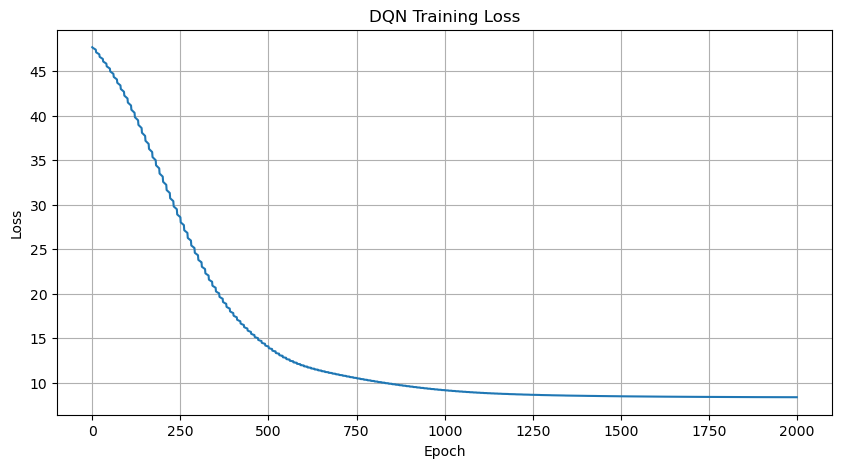

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(losses)

plt.title("DQN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [50]:
epoch_points = [
    0, 20, 40, 60, 80,
    100, 120, 140, 160,
    180, 200, 220, 240,
    1500, 1520, 1540,
    1560, 1580, 1600,
    1620, 1640, 1660,
    1680
]

action1_counts = [
    55032,
    50554,
    47366,
    44946,
    42918,
    41003,
    39418,
    37909,
    36385,
    34916,
    33605,
    32449,
    31448,
    9763,
    9732,
    9701,
    9704,
    9711,
    9737,
    9753,
    9741,
    9745,
    9751
]

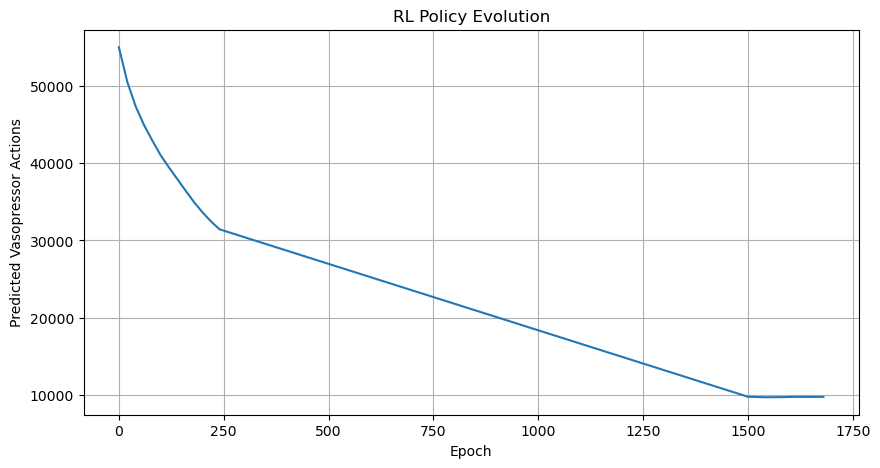

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    epoch_points,
    action1_counts
)

plt.title(
    "RL Policy Evolution"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Predicted Vasopressor Actions"
)

plt.grid(True)

plt.show()

In [52]:
torch.save(
    dqn.state_dict(),
    "dqn_sepsis_policy.pth"
)

In [53]:
df_rl_final.to_csv(
    "final_rl_dataset.csv",
    index=False
)

In [54]:
plt.savefig(
    "dqn_loss_curve.png"
)

<Figure size 640x480 with 0 Axes>

In [55]:
plt.savefig(
    "policy_evolution.png"
)

<Figure size 640x480 with 0 Axes>

In [56]:
clinician_vaso_rate = (
    actions.mean()
)

rl_vaso_rate = (
    learned_actions.mean()
)

print(
    "Clinician vaso rate:",
    clinician_vaso_rate
)

print(
    "RL vaso rate:",
    rl_vaso_rate
)

Clinician vaso rate: 0.035105822429085796
RL vaso rate: 0.11167339949064722


In [57]:
import pandas as pd

eval_df = pd.DataFrame({

    "rl_action": learned_actions,

    "reward": rewards
})

print(
    eval_df.groupby(
        "rl_action"
    )["reward"].mean()
)

rl_action
0    0.529901
1   -3.391962
Name: reward, dtype: float32


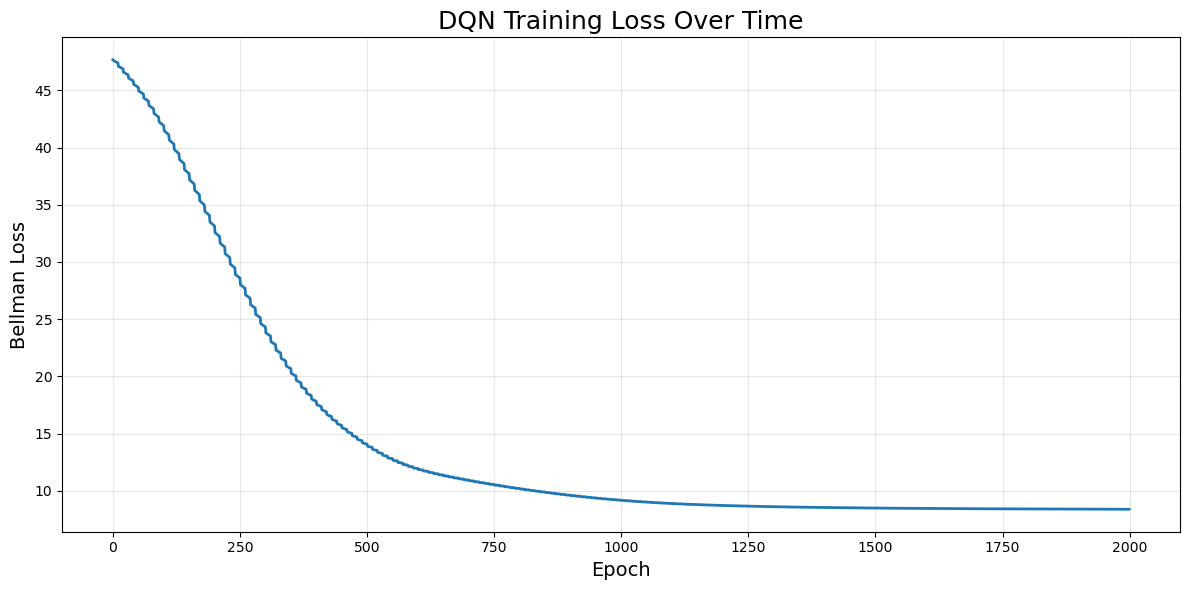

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    losses,
    linewidth=2
)

plt.title(
    "DQN Training Loss Over Time",
    fontsize=18
)

plt.xlabel(
    "Epoch",
    fontsize=14
)

plt.ylabel(
    "Bellman Loss",
    fontsize=14
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "dqn_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

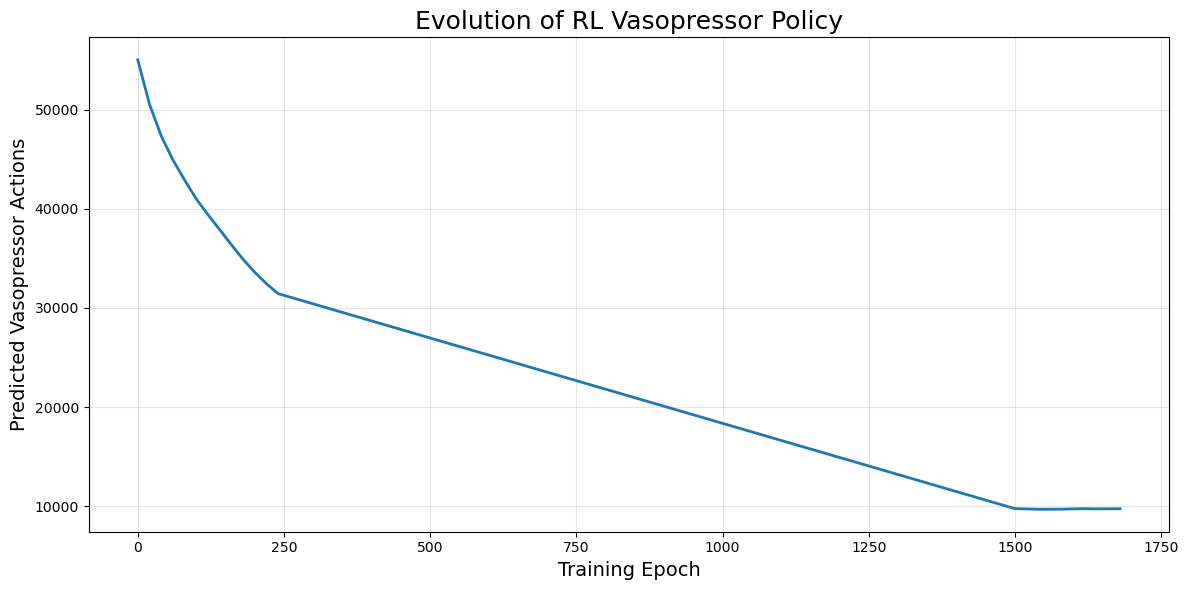

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    epoch_points,
    action1_counts,
    linewidth=2
)

plt.title(
    "Evolution of RL Vasopressor Policy",
    fontsize=18
)

plt.xlabel(
    "Training Epoch",
    fontsize=14
)

plt.ylabel(
    "Predicted Vasopressor Actions",
    fontsize=14
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "policy_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Text(0.5, 1.0, 'Clinician vs RL Vasopressor Usage')

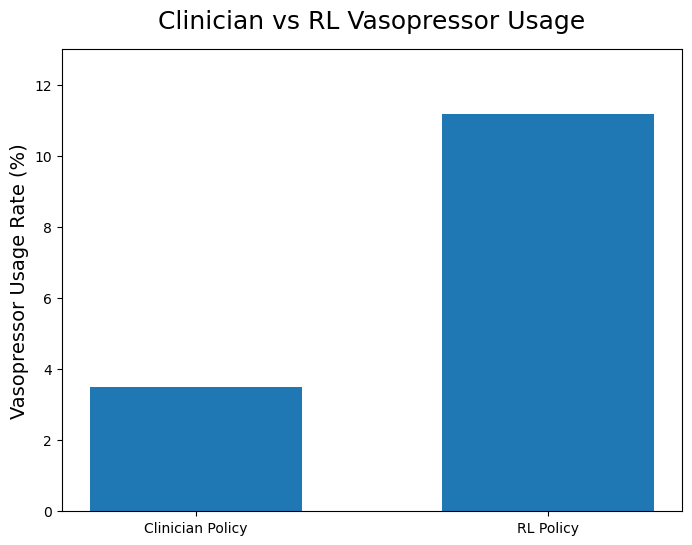

In [62]:
plt.figure(figsize=(8,6))

bars = plt.bar(
    labels,
    rates,
    width=0.6
)

plt.ylim(0, 13)

plt.ylabel(
    "Vasopressor Usage Rate (%)",
    fontsize=14
)

plt.title(
    "Clinician vs RL Vasopressor Usage",
    fontsize=18,
    pad=15
)

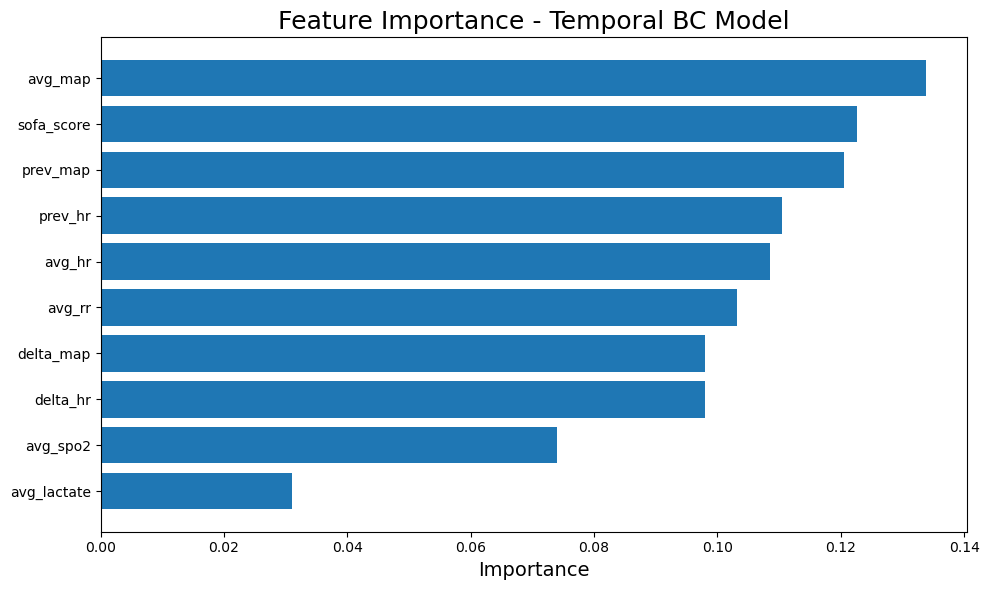

In [61]:
import matplotlib.pyplot as plt

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.title(
    "Feature Importance - Temporal BC Model",
    fontsize=18
)

plt.xlabel(
    "Importance",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()